# Homework 1 - Part 5: Decision Tree Classifier
### Burak Kurucay - 210104004049
---

This section models a decision tree classifier on the Breast Cancer Wisconsin dataset.
Two pruning strategies are compared: pre-pruning with `max_depth=4` and post-pruning with
`ccp_alpha=0.01`. The notebook also extracts a set of rules from one trained tree.


## Code:

### Import the necessary modules

In [3]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import KFold
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.tree import DecisionTreeClassifier, _tree


### Load the dataset
Load the data and show the number of samples, features, and class names.

In [4]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("Feature count:", X.shape[1])
print("Classes:", list(data.target_names))


Dataset shape: (569, 30)
Feature count: 30
Classes: [np.str_('malignant'), np.str_('benign')]


### Monitor the data
Just to see the dataset loaded.

In [5]:
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Define the pruning strategies
- Strategy 1 uses pre-pruning by limiting the tree depth with `max_depth=4`.
- Strategy 2 uses post-pruning by applying cost-complexity pruning with `ccp_alpha=0.01`.

In [6]:
strategies = {
    "Max Depth Pruning": DecisionTreeClassifier(
        criterion="gini",
        max_depth=4,
        random_state=42
    ),
    "Cost Complexity Pruning": DecisionTreeClassifier(
        criterion="gini",
        ccp_alpha=0.01,
        random_state=42
    )
}


### Train By 6-Fold Cross Validation

In [7]:
kf = KFold(n_splits=6, shuffle=True, random_state=42)

strategy_results = {}

for strategy_name, base_model in strategies.items():
    fold_results = []
    overall_start_time = time.time()

    for fold_idx, (train_index, test_index) in enumerate(kf.split(X), start=1):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        model = DecisionTreeClassifier(**base_model.get_params())

        fold_start_time = time.time()
        model.fit(X_train, y_train)
        train_scores = model.predict_proba(X_train)[:, 1]
        test_scores = model.predict_proba(X_test)[:, 1]
        train_predictions = model.predict(X_train)
        test_predictions = model.predict(X_test)
        fold_end_time = time.time()

        train_fpr, train_tpr, _ = roc_curve(y_train, train_scores)
        test_fpr, test_tpr, _ = roc_curve(y_test, test_scores)

        fold_results.append({
            "fold": fold_idx,
            "train_accuracy": accuracy_score(y_train, train_predictions),
            "test_accuracy": accuracy_score(y_test, test_predictions),
            "train_precision": precision_score(y_train, train_predictions, zero_division=0),
            "test_precision": precision_score(y_test, test_predictions, zero_division=0),
            "train_recall": recall_score(y_train, train_predictions, zero_division=0),
            "test_recall": recall_score(y_test, test_predictions, zero_division=0),
            "train_f1": f1_score(y_train, train_predictions, zero_division=0),
            "test_f1": f1_score(y_test, test_predictions, zero_division=0),
            "train_auc": roc_auc_score(y_train, train_scores),
            "test_auc": roc_auc_score(y_test, test_scores),
            "train_confusion_matrix": confusion_matrix(y_train, train_predictions),
            "test_confusion_matrix": confusion_matrix(y_test, test_predictions),
            "train_fpr": train_fpr,
            "train_tpr": train_tpr,
            "test_fpr": test_fpr,
            "test_tpr": test_tpr,
            "model": model,
            "runtime_seconds": fold_end_time - fold_start_time
        })

    overall_end_time = time.time()

    strategy_results[strategy_name] = {
        "fold_results": fold_results,
        "mean_runtime": np.mean([r["runtime_seconds"] for r in fold_results]),
        "total_runtime": overall_end_time - overall_start_time
    }

## Results:

### Strategy Comparison

In [8]:
summary_rows = []

for strategy_name, result_bundle in strategy_results.items():
    fold_results = result_bundle["fold_results"]
    summary_rows.append({
        "Strategy": strategy_name,
        "Mean Train Accuracy": np.mean([r["train_accuracy"] for r in fold_results]),
        "Mean Test Accuracy": np.mean([r["test_accuracy"] for r in fold_results]),
        "Mean Train Precision": np.mean([r["train_precision"] for r in fold_results]),
        "Mean Test Precision": np.mean([r["test_precision"] for r in fold_results]),
        "Mean Train Recall": np.mean([r["train_recall"] for r in fold_results]),
        "Mean Test Recall": np.mean([r["test_recall"] for r in fold_results]),
        "Mean Train F1": np.mean([r["train_f1"] for r in fold_results]),
        "Mean Test F1": np.mean([r["test_f1"] for r in fold_results]),
        "Mean Train AUC": np.mean([r["train_auc"] for r in fold_results]),
        "Mean Test AUC": np.mean([r["test_auc"] for r in fold_results]),
        "Average Runtime (seconds)": result_bundle["mean_runtime"]
    })

df_strategy_summary = pd.DataFrame(summary_rows)
df_strategy_summary.iloc[:, 1:] = df_strategy_summary.iloc[:, 1:].round(4)
display(df_strategy_summary)

,Strategy,Mean Train Accuracy,Mean Test Accuracy,Mean Train Precision,Mean Test Precision,Mean Train Recall,Mean Test Recall,Mean Train F1,Mean Test F1,Mean Train AUC,Mean Test AUC,Average Runtime (seconds)
0,Max Depth Pruning,0.9891,0.9438,0.9883,0.9406,0.9944,0.9718,0.9913,0.9559,0.9938,0.9175,0.0039
1,Cost Complexity Pruning,0.9743,0.9491,0.9751,0.9509,0.9842,0.9692,0.9796,0.9593,0.9841,0.9574,0.0041


### Select the better pruning strategy

In [9]:
best_strategy_name = df_strategy_summary.sort_values(
    by=["Mean Test Accuracy", "Mean Test F1"],
    ascending=False
).iloc[0]["Strategy"]

best_results = strategy_results[best_strategy_name]["fold_results"]
print("Selected strategy:", best_strategy_name)


Selected strategy: Cost Complexity Pruning


### Test Fold Confusion Matrices

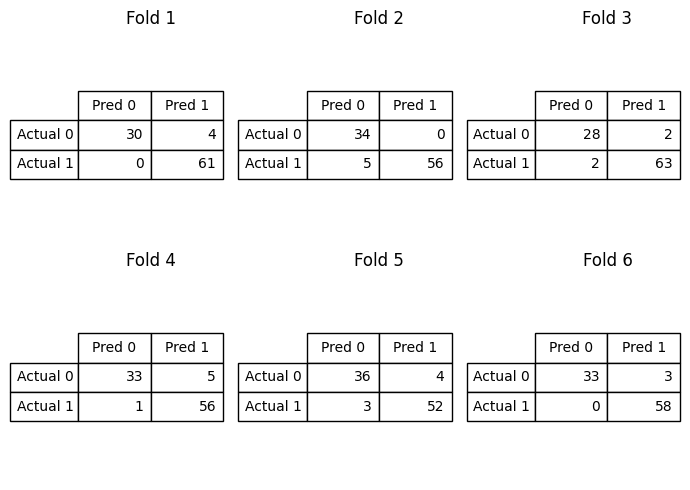

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(7, 5))
axes = axes.flatten()

for i, result in enumerate(best_results):
    ax = axes[i]
    ax.axis("off")
    cm = result["test_confusion_matrix"]

    table = ax.table(
        cellText=[[cm[0][0], cm[0][1]], [cm[1][0], cm[1][1]]],
        rowLabels=["Actual 0", "Actual 1"],
        colLabels=["Pred 0", "Pred 1"],
        loc="center"
    )
    table.scale(1, 1.5)
    ax.set_title(f"Fold {result['fold']}")

plt.tight_layout()
plt.show()


### Classification Metrics

,Fold,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train AUC,Test AUC
0,1,0.9789,0.9579,0.9767,0.9385,0.9899,1.0000,0.9832,0.9683,0.9840,0.9638
1,2,0.9684,0.9474,0.9763,1.0000,0.9730,0.9180,0.9746,0.9573,0.9790,0.9446
2,3,0.9684,0.9579,0.9792,0.9692,0.9692,0.9692,0.9742,0.9692,0.9809,0.9579
3,4,0.9789,0.9368,0.9770,0.9180,0.9900,0.9825,0.9834,0.9492,0.9923,0.9587
4,5,0.9705,0.9263,0.9645,0.9286,0.9901,0.9455,0.9771,0.9369,0.9816,0.9507
5,6,0.9811,0.9681,0.9770,0.9508,0.9933,1.0000,0.9851,0.9748,0.9866,0.9689


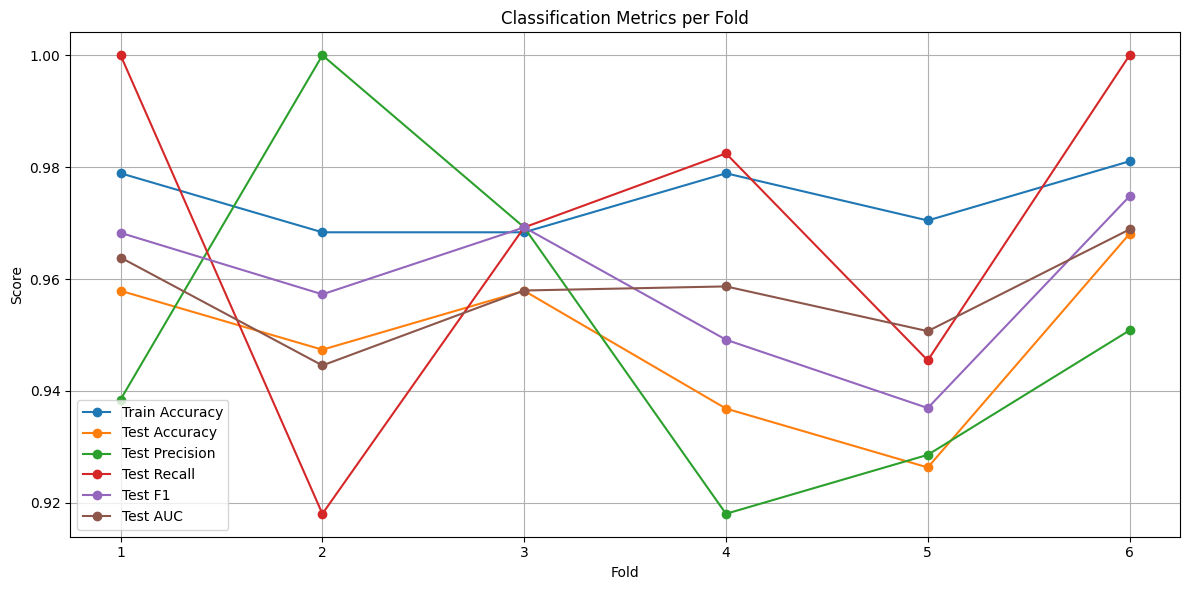

In [11]:
metric_rows = []

for result in best_results:
    metric_rows.append({
        "Fold": result["fold"],
        "Train Accuracy": result["train_accuracy"],
        "Test Accuracy": result["test_accuracy"],
        "Train Precision": result["train_precision"],
        "Test Precision": result["test_precision"],
        "Train Recall": result["train_recall"],
        "Test Recall": result["test_recall"],
        "Train F1": result["train_f1"],
        "Test F1": result["test_f1"],
        "Train AUC": result["train_auc"],
        "Test AUC": result["test_auc"]
    })

df_metrics = pd.DataFrame(metric_rows)
df_metrics.iloc[:, 1:] = df_metrics.iloc[:, 1:].round(4)
display(df_metrics)

folds = [r["fold"] for r in best_results]
train_accs = [r["train_accuracy"] for r in best_results]
test_accs = [r["test_accuracy"] for r in best_results]
test_precisions = [r["test_precision"] for r in best_results]
test_recalls = [r["test_recall"] for r in best_results]
test_f1s = [r["test_f1"] for r in best_results]
test_aucs = [r["test_auc"] for r in best_results]

plt.figure(figsize=(12, 6))
plt.plot(folds, train_accs, marker="o", label="Train Accuracy")
plt.plot(folds, test_accs, marker="o", label="Test Accuracy")
plt.plot(folds, test_precisions, marker="o", label="Test Precision")
plt.plot(folds, test_recalls, marker="o", label="Test Recall")
plt.plot(folds, test_f1s, marker="o", label="Test F1")
plt.plot(folds, test_aucs, marker="o", label="Test AUC")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("Classification Metrics per Fold")
plt.xticks(folds)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Runtime Performance

In [12]:
runtime_rows = []

for result in best_results:
    runtime_rows.append({
        "Fold": result["fold"],
        "Runtime (seconds)": result["runtime_seconds"]
    })

df_runtime = pd.DataFrame(runtime_rows)
df_runtime["Runtime (seconds)"] = df_runtime["Runtime (seconds)"].round(4)
display(df_runtime)

df_runtime_summary = pd.DataFrame({
    "Metric": [
        "Average runtime per fold",
        "Total 6-fold CV runtime"
    ],
    "Runtime (seconds)": [
        strategy_results[best_strategy_name]["mean_runtime"],
        strategy_results[best_strategy_name]["total_runtime"]
    ]
})

df_runtime_summary["Runtime (seconds)"] = df_runtime_summary["Runtime (seconds)"].round(4)
display(df_runtime_summary)


,Fold,Runtime (seconds)
0,1,0.0042
1,2,0.0047
2,3,0.0045
3,4,0.0034
4,5,0.0038
5,6,0.0039


,Metric,Runtime (seconds)
0,Average runtime per fold,0.0041
1,Total 6-fold CV runtime,0.0589


### Selected Fold Performance Results
Select the fold whose test accuracy is closest to the mean test accuracy across all folds for the selected strategy.

In [13]:
mean_test_acc = np.mean([r["test_accuracy"] for r in best_results])

selected_fold = min(
    best_results,
    key=lambda r: abs(r["test_accuracy"] - mean_test_acc)
)


,Metric,Value
0,Train Accuracy,0.9684
1,Test Accuracy,0.9474
2,Train Precision,0.9763
3,Test Precision,1.0000
4,Train Recall,0.9730
5,Test Recall,0.9180
6,Train F1,0.9746
7,Test F1,0.9573
8,Train AUC,0.9790
9,Test AUC,0.9446


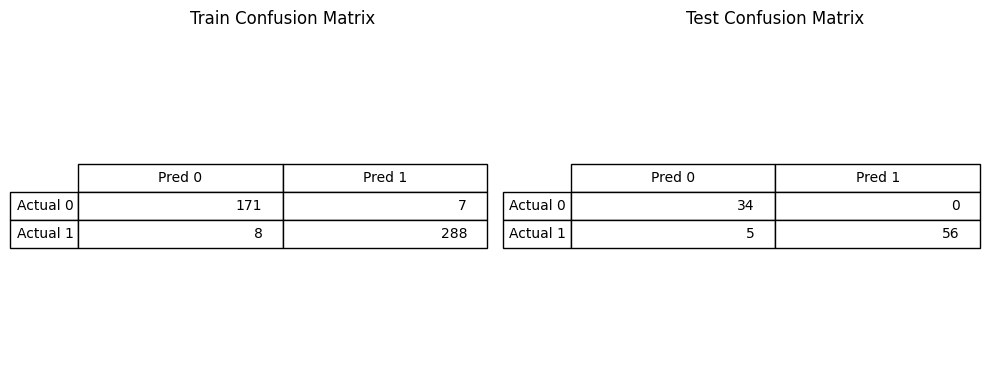

In [14]:
df_selected_performance = pd.DataFrame({
    "Metric": [
        "Train Accuracy", "Test Accuracy",
        "Train Precision", "Test Precision",
        "Train Recall", "Test Recall",
        "Train F1", "Test F1",
        "Train AUC", "Test AUC"
    ],
    "Value": [
        selected_fold["train_accuracy"], selected_fold["test_accuracy"],
        selected_fold["train_precision"], selected_fold["test_precision"],
        selected_fold["train_recall"], selected_fold["test_recall"],
        selected_fold["train_f1"], selected_fold["test_f1"],
        selected_fold["train_auc"], selected_fold["test_auc"]
    ]
})

df_selected_performance["Value"] = df_selected_performance["Value"].round(4)
display(df_selected_performance)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, matrix_key, title in [
    (axes[0], "train_confusion_matrix", "Train Confusion Matrix"),
    (axes[1], "test_confusion_matrix", "Test Confusion Matrix")
]:
    ax.axis("off")
    cm = selected_fold[matrix_key]
    table = ax.table(
        cellText=[[cm[0][0], cm[0][1]], [cm[1][0], cm[1][1]]],
        rowLabels=["Actual 0", "Actual 1"],
        colLabels=["Pred 0", "Pred 1"],
        loc="center"
    )
    table.scale(1, 1.5)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Selected Fold ROC Curve
ROC is drawn only for the selected fold. The decision tree provides class scores with `predict_proba`, and the curve is obtained by sweeping the threshold on the positive-class score and plotting TPR versus FPR.

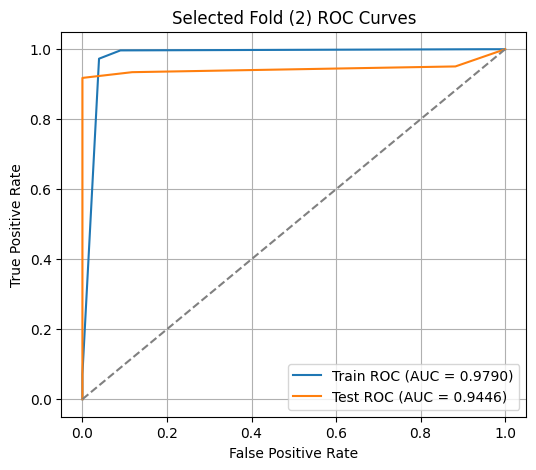

In [15]:
plt.figure(figsize=(6, 5))
plt.plot(
    selected_fold["train_fpr"],
    selected_fold["train_tpr"],
    label=f"Train ROC (AUC = {selected_fold['train_auc']:.4f})"
)
plt.plot(
    selected_fold["test_fpr"],
    selected_fold["test_tpr"],
    label=f"Test ROC (AUC = {selected_fold['test_auc']:.4f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Selected Fold ({selected_fold['fold']}) ROC Curves")
plt.legend()
plt.grid(True)
plt.show()

### Extract the Path to Each Leaf Node

In [16]:
def tree_classifier_leaf_paths(model, feature_names, class_names):
    tree = model.tree_
    leaf_paths = []

    def walk(node_id, conditions, visited_nodes):
        if tree.feature[node_id] != _tree.TREE_UNDEFINED:
            feature_name = feature_names[tree.feature[node_id]]
            threshold = tree.threshold[node_id]

            walk(
                tree.children_left[node_id],
                conditions + [f"{feature_name} <= {threshold:.4f}"],
                visited_nodes + [node_id]
            )
            walk(
                tree.children_right[node_id],
                conditions + [f"{feature_name} > {threshold:.4f}"],
                visited_nodes + [node_id]
            )
        else:
            class_index = int(np.argmax(tree.value[node_id][0]))
            predicted_class = class_names[class_index]
            samples = int(tree.n_node_samples[node_id])
            leaf_paths.append({
                "Leaf Node": node_id,
                "Visited Nodes": " -> ".join(map(str, visited_nodes + [node_id])),
                "Path": "IF " + " AND ".join(conditions),
                "Prediction": predicted_class,
                "Samples": samples
            })

    walk(0, [], [])
    return leaf_paths


leaf_paths = tree_classifier_leaf_paths(
    selected_fold["model"],
    data.feature_names,
    data.target_names
)

pd.set_option("display.max_colwidth", None)

df_leaf_paths = pd.DataFrame(leaf_paths)

display(
    df_leaf_paths.style.set_properties(**{
        "white-space": "pre-wrap",
        "text-align": "left"
    })
)


,Leaf Node,Visited Nodes,Path,Prediction,Samples
0,2,0 -> 1 -> 2,IF mean concave points <= 0.0514 AND worst radius <= 16.8300,benign,274
1,3,0 -> 1 -> 3,IF mean concave points <= 0.0514 AND worst radius > 16.8300,malignant,16
2,6,0 -> 4 -> 5 -> 6,IF mean concave points > 0.0514 AND worst area <= 686.2000 AND worst texture <= 25.9250,benign,15
3,7,0 -> 4 -> 5 -> 7,IF mean concave points > 0.0514 AND worst area <= 686.2000 AND worst texture > 25.9250,malignant,4
4,10,0 -> 4 -> 8 -> 9 -> 10,IF mean concave points > 0.0514 AND worst area > 686.2000 AND worst texture <= 20.8750 AND concavity error <= 0.0337,benign,6
5,11,0 -> 4 -> 8 -> 9 -> 11,IF mean concave points > 0.0514 AND worst area > 686.2000 AND worst texture <= 20.8750 AND concavity error > 0.0337,malignant,4
6,12,0 -> 4 -> 8 -> 12,IF mean concave points > 0.0514 AND worst area > 686.2000 AND worst texture > 20.8750,malignant,155


## Comments:
- The comparison between pre-pruning and cost-complexity pruning shows that pruning strategy has a direct effect on generalization. The selected strategy gives a slightly better balance between test accuracy and test F1, which suggests that controlling tree complexity improves performance on unseen data.
- Training scores are consistently higher than test scores, but the gap is not extreme. This is compatible with the usual behavior of decision trees: they can fit the training set strongly, while pruning helps reduce excessive specialization of the branches.
- In the selected fold, test precision is very strong, while test recall is somewhat lower. This suggests that the pruned tree makes relatively careful positive predictions, but may still miss some positive instances because the final decision rules are more conservative.
- Some fluctuation across folds is still visible, which is common for tree-based models because split selection can change when the training subset changes. Even so, the overall test performance remains reasonably stable after pruning.
- A useful advantage of this model is interpretability. The extracted root-to-leaf paths allow the reported performance to be connected with explicit decision rules, which adds value to the analysis beyond reporting accuracy alone.
